In [3]:
!pip install rasterio xarray rioxarray matplotlib numpy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

data_dir = '/content/drive/MyDrive/GEE_LST_Exports'

files = os.listdir(data_dir)
for f in files:
    print(f)

LST_Summer_Mean_2020_2025.tif
LST_Anomaly_2023.tif
LST_Kozan_Summer_2020_2025.tif
LST_Winter_Mean_2020_2025.tif
Landsat_LST_Kozan_Summer_2020_2025.tif
Landsat_LST_Summer_2020_2025.tif
Landsat_LST_Winter_2020_2025.tif
lst_overview.png
landsat_overview.png


In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# MODIS dosyaları
summer_path  = f'{data_dir}/LST_Summer_Mean_2020_2025.tif'
winter_path  = f'{data_dir}/LST_Winter_Mean_2020_2025.tif'
anomaly_path = f'{data_dir}/LST_Anomaly_2023.tif'
kozan_path   = f'{data_dir}/LST_Kozan_Summer_2020_2025.tif'

# Landsat dosyaları
ls_summer_path = f'{data_dir}/Landsat_LST_Summer_2020_2025.tif'
ls_winter_path = f'{data_dir}/Landsat_LST_Winter_2020_2025.tif'
ls_kozan_path  = f'{data_dir}/Landsat_LST_Kozan_Summer_2020_2025.tif'

# GeoTIFF oku
def read_tif(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)  # ilk band
        profile = src.profile
        # NoData değerlerini NaN yap
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        print(f'Dosya: {path.split("/")[-1]}')
        print(f'  Boyut: {src.width} x {src.height} piksel')
        print(f'  CRS: {src.crs}')
        print(f'  Min: {np.nanmin(data):.2f}°C')
        print(f'  Max: {np.nanmax(data):.2f}°C')
        print(f'  Mean: {np.nanmean(data):.2f}°C')
        print()
    return data, profile

# Tüm dosyaları oku
summer_data, summer_profile = read_tif(summer_path)
winter_data, winter_profile = read_tif(winter_path)
anomaly_data, anomaly_profile = read_tif(anomaly_path)
kozan_data, kozan_profile = read_tif(kozan_path)
ls_summer_data, ls_summer_profile = read_tif(ls_summer_path)
ls_winter_data, ls_winter_profile = read_tif(ls_winter_path)
ls_kozan_data, ls_kozan_profile = read_tif(ls_kozan_path)

Dosya: LST_Summer_Mean_2020_2025.tif
  Boyut: 216 x 288 piksel
  CRS: EPSG:4326
  Min: 17.50°C
  Max: 48.26°C
  Mean: 35.96°C

Dosya: LST_Winter_Mean_2020_2025.tif
  Boyut: 216 x 288 piksel
  CRS: EPSG:4326
  Min: -9.96°C
  Max: 24.23°C
  Mean: 10.91°C

Dosya: LST_Anomaly_2023.tif
  Boyut: 216 x 288 piksel
  CRS: EPSG:4326
  Min: -20.11°C
  Max: 15.42°C
  Mean: -0.19°C

Dosya: LST_Kozan_Summer_2020_2025.tif
  Boyut: 91 x 65 piksel
  CRS: EPSG:4326
  Min: 27.51°C
  Max: 43.51°C
  Mean: 35.66°C

Dosya: Landsat_LST_Summer_2020_2025.tif
  Boyut: 2969 x 5940 piksel
  CRS: EPSG:4326
  Min: 22.92°C
  Max: 60.62°C
  Mean: 40.65°C

Dosya: Landsat_LST_Winter_2020_2025.tif
  Boyut: 2969 x 5940 piksel
  CRS: EPSG:4326
  Min: -6.51°C
  Max: 31.45°C
  Mean: 14.47°C

Dosya: Landsat_LST_Kozan_Summer_2020_2025.tif
  Boyut: 2969 x 5940 piksel
  CRS: EPSG:4326
  Min: 28.69°C
  Max: 51.32°C
  Mean: 39.57°C



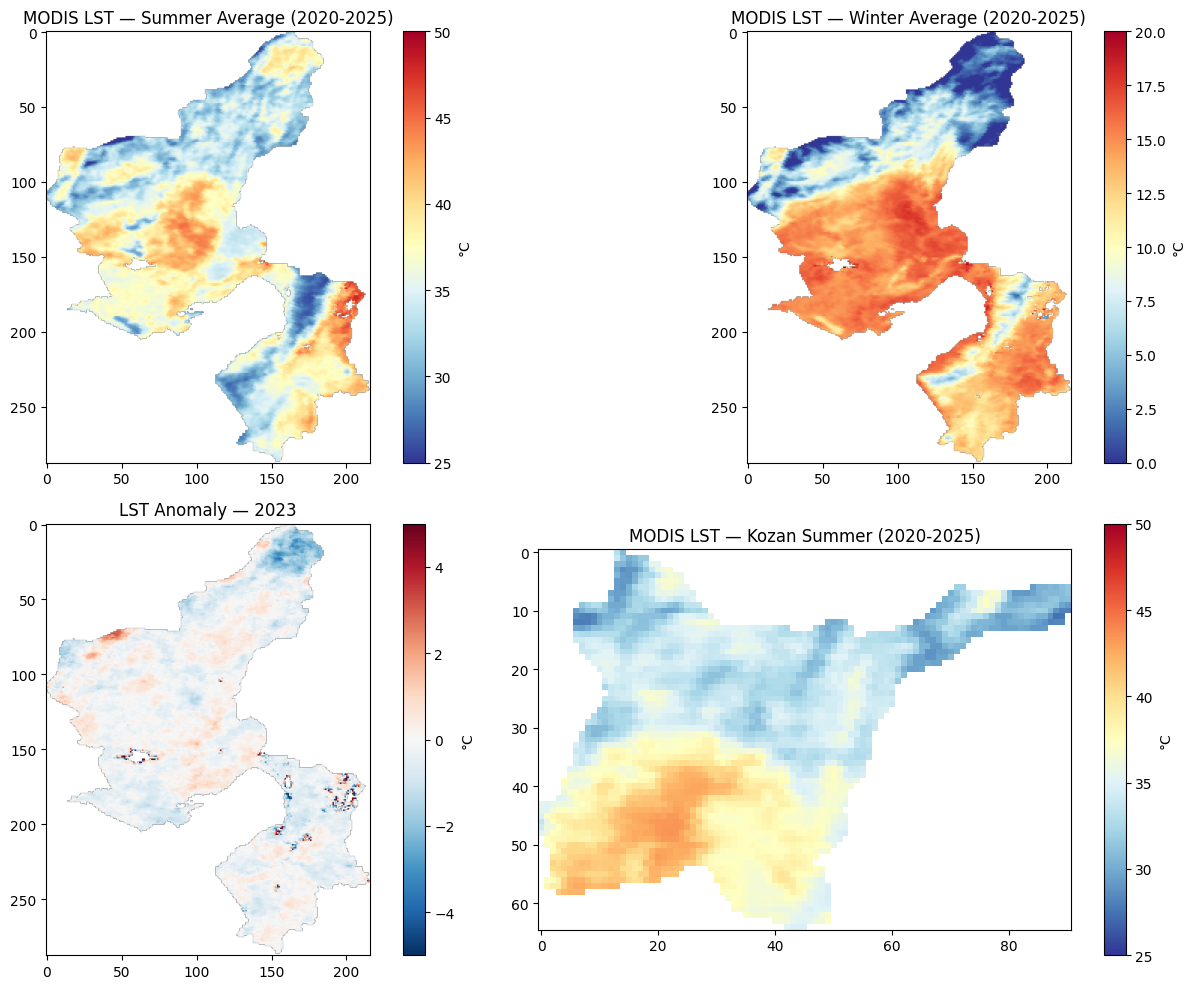

Image was recorded.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LST Summer
im1 = axes[0,0].imshow(summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0,0].set_title('MODIS LST — Summer Average (2020-2025)')
plt.colorbar(im1, ax=axes[0,0], label='°C')

# LST Winter
im2 = axes[0,1].imshow(winter_data, cmap='RdYlBu_r', vmin=0, vmax=20)
axes[0,1].set_title('MODIS LST — Winter Average (2020-2025)')
plt.colorbar(im2, ax=axes[0,1], label='°C')

# Anomaly
im3 = axes[1,0].imshow(anomaly_data, cmap='RdBu_r', vmin=-5, vmax=5)
axes[1,0].set_title('LST Anomaly — 2023')
plt.colorbar(im3, ax=axes[1,0], label='°C')

# Kozan Summer
im4 = axes[1,1].imshow(kozan_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[1,1].set_title('MODIS LST — Kozan Summer (2020-2025)')
plt.colorbar(im4, ax=axes[1,1], label='°C')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_LST_Exports/lst_overview.png', dpi=150)
plt.show()
print('Image was recorded.')

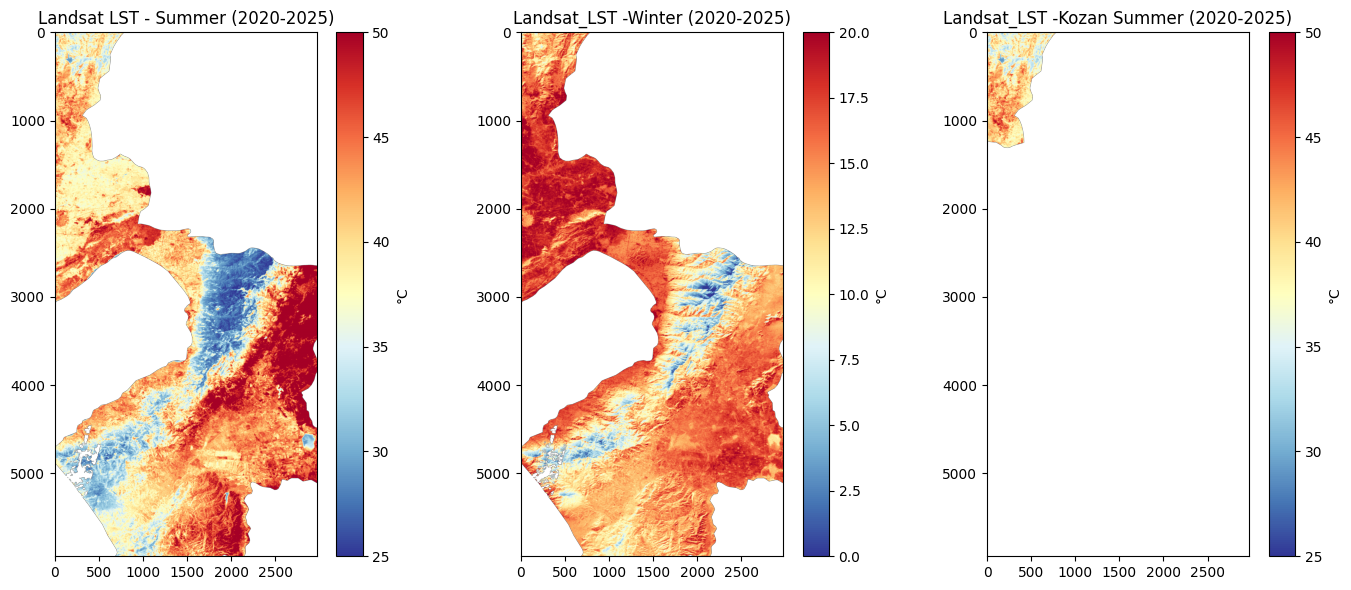

Image was recorded.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

#Landsat Summer
im5 = axes[0].imshow(ls_summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0].set_title('Landsat LST - Summer (2020-2025)')
plt.colorbar(im5, ax=axes[0], label='°C')

#Landsat Winter
im6= axes[1].imshow(ls_winter_data, cmap='RdYlBu_r', vmin=0, vmax=20)
axes[1].set_title('Landsat_LST -Winter (2020-2025)')
plt.colorbar(im6, ax=axes[1], label='°C')

#Landsat Kozan Summer
im7= axes[2].imshow(ls_kozan_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[2].set_title('Landsat_LST -Kozan Summer (2020-2025)')
plt.colorbar(im7, ax=axes[2], label='°C')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_LST_Exports/landsat_overview.png', dpi=150)
plt.show()
print('Image was recorded.')

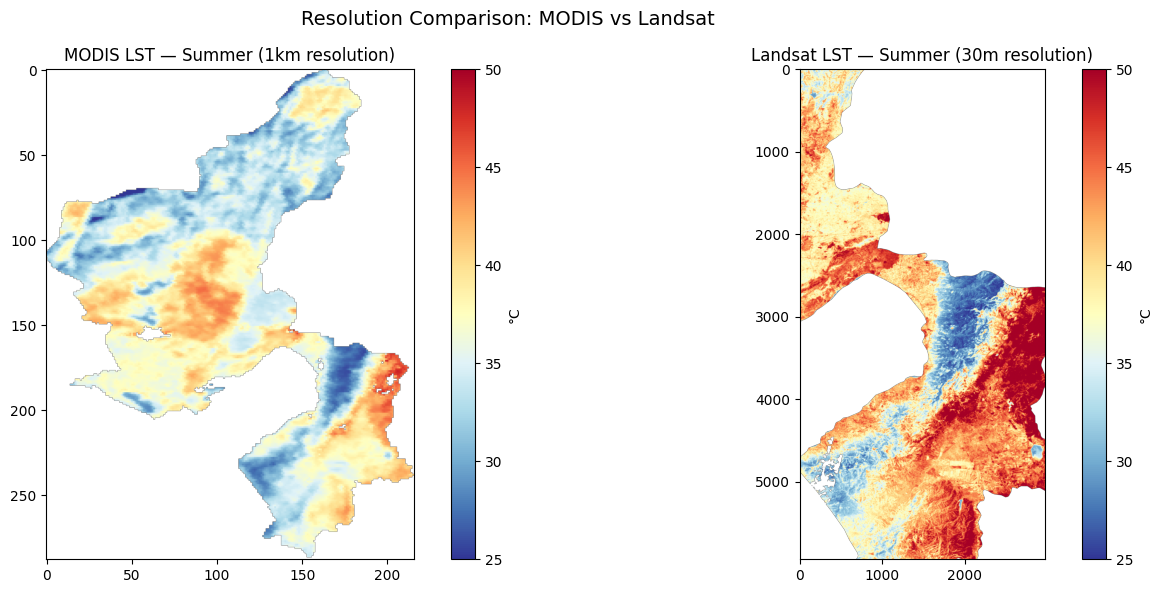

Comparison image saved.


In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MODIS Summer
im1 = axes[0].imshow(summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0].set_title('MODIS LST — Summer (1km resolution)')
plt.colorbar(im1, ax=axes[0], label='°C')

# Landsat Summer
im2 = axes[1].imshow(ls_summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[1].set_title('Landsat LST — Summer (30m resolution)')
plt.colorbar(im2, ax=axes[1], label='°C')

plt.suptitle('Resolution Comparison: MODIS vs Landsat', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_LST_Exports/modis_vs_landsat.png', dpi=150)
plt.show()
print('Comparison image saved.')